In [1]:
# Import libraries
import ast
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
import nbformat
print(nbformat.__version__)

5.10.4


In [ ]:
# Load dataset
df = pd.read_csv("../preparation/finalverses.csv", encoding='utf-8-sig')
print("Initial shape:", df.shape)

Initial shape: (34981, 15)


In [36]:
print("=========================== Dataset Variables ===========================\n")

print(df.columns)

=========================== Dataset Variables ===========================

Index(['verse_id', 'song_id', 'ori_track_name', 'clean_track_name',
       'all_artists', 'primary_artist', 'artist_genres', 'main_genre',
       'explicit', 'section', 'verse', 'language', 'confidence', 'tokens',
       'label'],
      dtype='str')


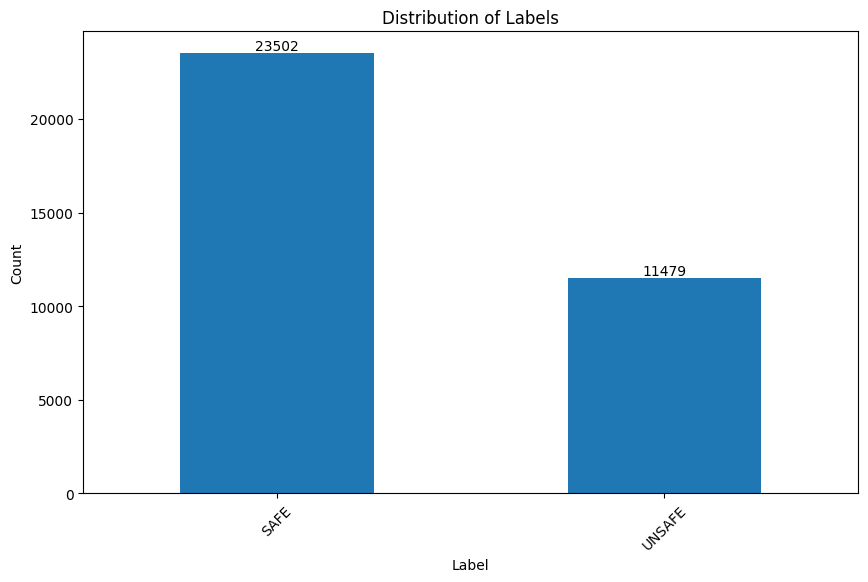

In [21]:
# Distribution of labels
label_counts = df['label'].value_counts()
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)

for i, value in enumerate(label_counts):
    plt.text(i, value, str(value), ha='center', va='bottom')
    
plt.show()

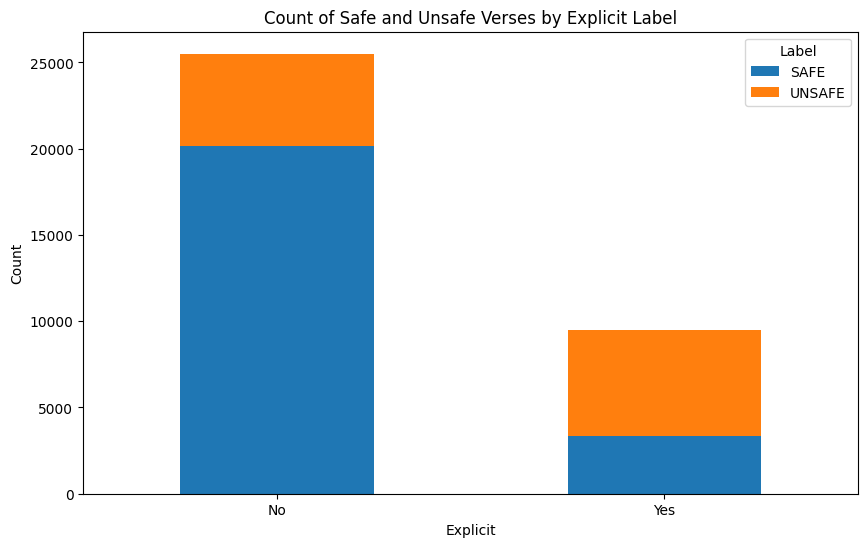

In [15]:
# Number of safe and unsafe songs across explicit and non-explicit song
explicit_counts = df.groupby(['explicit', 'label']).size().unstack(fill_value=0)
explicit_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Count of Safe and Unsafe Verses by Explicit Label')
plt.xlabel('Explicit')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.show()

In [24]:
# Artists with the most "UNSAFE" verses
unsafe_verses = df[df['label'].str.upper() == 'UNSAFE']
artist_counts = unsafe_verses['primary_artist'].value_counts().head(10)

# Calculate total number of "UNSAFE" verses by these artists
number_of_unsafe_verses = artist_counts.sum()
print(f"Total number of UNSAFE verses by these artists: {number_of_unsafe_verses}")

print(artist_counts)

Total number of UNSAFE verses by these artists: 1479
primary_artist
Drake                 257
Taylor Swift          210
Kendrick Lamar        165
Playboi Carti         149
The Weeknd            135
Ariana Grande         126
Travis Scott          121
Tyler, The Creator    111
Rihanna               104
Future                101
Name: count, dtype: int64


In [37]:
# 1. Count the total number of songs for each artist
# We group by 'Primary_artist' and count the number of unique 'Track_name' entries
artist_total_songs = df.groupby('primary_artist')['clean_track_name'].count().reset_index()
artist_total_songs.columns = ['primary_artist', 'Total_Verses']

# 2. Filter the dataframe to only include 'Unsafe' labels
unsafe_df = df[df['label'] == 'UNSAFE']

# 3. Count the number of 'Unsafe' songs for each artist
artist_unsafe_counts = unsafe_df.groupby('primary_artist')['label'].count().reset_index()
artist_unsafe_counts.columns = ['primary_artist', 'Unsafe_Count']

# 4. Merge the two results into a single summary table
artist_summary = pd.merge(artist_total_songs, artist_unsafe_counts, on='primary_artist', how='left')

# 5. Fill NaN values with 0 (for artists who have 0 unsafe songs)
artist_summary['Unsafe_Count'] = artist_summary['Unsafe_Count'].fillna(0).astype(int)

# 6. Optional: Calculate the Safety Ratio to show the "proportional risk"
artist_summary['Unsafe_Ratio (%)'] = (artist_summary['Unsafe_Count'] / artist_summary['Total_Verses']) * 100

# Display the top 10 artists by Unsafe count for your report
print(artist_summary.sort_values(by='Unsafe_Count', ascending=False).head(10))

          primary_artist  Total_Verses  Unsafe_Count  Unsafe_Ratio (%)
464                Drake           377           257         68.169761
1596        Taylor Swift           763           210         27.522936
874       Kendrick Lamar           232           165         71.120690
1302       Playboi Carti           178           149         83.707865
1698          The Weeknd           329           135         41.033435
100        Ariana Grande           339           126         37.168142
1741        Travis Scott           174           121         69.540230
1764  Tyler, The Creator           202           111         54.950495
1370             Rihanna           233           104         44.635193
593               Future           128           101         78.906250


In [40]:
# 1. Count the total number of songs for each artist
# We group by 'Primary_artist' and count the number of unique 'Track_name' entries
artist_total_songs = df.groupby('primary_artist')['clean_track_name'].count().reset_index()
artist_total_songs.columns = ['primary_artist', 'Total_Verses']

# 2. Filter the dataframe to only include 'Unsafe' labels
unsafe_df = df[df['label'] == 'SAFE']

# 3. Count the number of 'Unsafe' songs for each artist
artist_unsafe_counts = unsafe_df.groupby('primary_artist')['label'].count().reset_index()
artist_unsafe_counts.columns = ['primary_artist', 'Safe_Count']

# 4. Merge the two results into a single summary table
artist_summary = pd.merge(artist_total_songs, artist_unsafe_counts, on='primary_artist', how='left')

# 5. Fill NaN values with 0 (for artists who have 0 unsafe songs)
artist_summary['Safe_Count'] = artist_summary['Safe_Count'].fillna(0).astype(int)

# 6. Optional: Calculate the Safety Ratio to show the "proportional risk"
artist_summary['Safe_Ratio (%)'] = (artist_summary['Safe_Count'] / artist_summary['Total_Verses']) * 100

# Display the top 10 artists by Safe count for your report
print(artist_summary.sort_values(by='Safe_Count', ascending=False).head(10))

            primary_artist  Total_Verses  Safe_Count  Safe_Ratio (%)
1596          Taylor Swift           763         553       72.477064
821   Jorge Rivera-Herrans           565         499       88.318584
1001          Lucy Bennett           353         336       95.184136
184          Billie Eilish           293         216       73.720137
100          Ariana Grande           339         213       62.831858
1698            The Weeknd           329         194       58.966565
974            Linkin Park           199         169       84.924623
947        Leslie Odom Jr.           174         162       93.103448
837          Justin Bieber           177         139       78.531073
922              Lady Gaga           233         138       59.227468


In [ ]:
import plotly.express as px

# Prepare and group the data
genre_counts = df.groupby(['label', 'main_genre']).size().reset_index(name='count')

# Create the "Unsafe" Treemap (Top 10 Genres)
unsafe_top10 = genre_counts[genre_counts['label'] == 'UNSAFE'].nlargest(10, 'count')
fig_unsafe = px.treemap(
    unsafe_top10, 
    path=['main_genre'], 
    values='count',
    title='Top 10 Genres in "Unsafe" Category',
    color_discrete_sequence=['#d62728'] # Red
)
fig_unsafe.update_traces(textinfo="label+percent root")
fig_unsafe.show()

# Create the "Safe" Treemap (Top 10 Genres)
safe_top10 = genre_counts[genre_counts['label'] == 'SAFE'].nlargest(10, 'count')
fig_safe = px.treemap(
    safe_top10, 
    path=['main_genre'], 
    values='count',
    title='Top 10 Genres in "Safe" Category',
    color_discrete_sequence=['#2ca02c'] # Green
)
fig_safe.update_traces(textinfo="label+percent root")
fig_safe.show()